In [65]:
from pathlib import Path
import sys

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Audio, Markdown, display


ROOT = Path(
    r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis"
)

TRAIN_MANIFEST = (
    ROOT
    / "features_extracted_stage1_fsd50k_cough_segments_random"
    / "mfcc117"
    / "metadata_features_train.csv"
)

AUGMENTATION_MANIFEST = (
    ROOT
    / "features_extracted_stage1_fsd50k_cough_segments_noise_aug_random"
    / "mfcc117"
    / "metadata_features_train_augmented.csv"
)

FIGURE_DIR = ROOT / "figures_tfm_stage1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import feature_extraction_stage1_mfcc_cough_augmentation as augmentation


SR = 16_000
N_MFCC = 13
N_FFT = 2048
HOP_LENGTH = 512
WIN_LENGTH = 2048
N_MELS = 128

train_metadata = pd.read_csv(TRAIN_MANIFEST, low_memory=False)

augmentation_metadata = pd.read_csv(
    AUGMENTATION_MANIFEST,
    low_memory=False,
)

print("Segmentos originales de TRAIN:", len(train_metadata))
print("Variantes aumentadas:", len(augmentation_metadata))

Segmentos originales de TRAIN: 7718
Variantes aumentadas: 2115


GRAFICAS SEÑAL ORIGINAL + RUIDO

In [66]:
# Seleccionar aleatoriamente una variante real a 10 dB
noise_examples = augmentation_metadata[
    augmentation_metadata["transformation"].eq("noise_high")
].copy()

if noise_examples.empty:
    raise RuntimeError("No hay variantes noise_high disponibles.")

example = noise_examples.sample(n=1).iloc[0]


# Recuperar la tos original
parent_rows = train_metadata[
    train_metadata["uuid_segmento"]
    .astype(str)
    .eq(str(example["parent_uuid_segmento"]))
]

if len(parent_rows) != 1:
    raise RuntimeError("No se encontró de forma única la tos original.")

cough_row = parent_rows.iloc[0]
y_original = augmentation.load_row_audio(cough_row)


# Reconstruir exactamente su augmentation
parent_fold = int(cough_row["fold"])

negative_candidates = train_metadata[
    train_metadata["stage1_target"].eq(0)
    & train_metadata["fold"].eq(parent_fold)
].copy()

variant_rng = augmentation.stable_rng(
    str(example["augmentation_id"])
)

y_augmented, augmentation_info = augmentation.apply_transformation(
    signal=y_original,
    transformation="noise_high",
    noise_candidates=negative_candidates,
    rng=variant_rng,
)


# Recuperar también el segmento negativo utilizado como ruido
donor_id = str(
    augmentation_info["noise_donor_uuid_segmento"]
)

donor_rows = train_metadata[
    train_metadata["uuid_segmento"]
    .astype(str)
    .eq(donor_id)
]

if len(donor_rows) != 1:
    raise RuntimeError("No se encontró de forma única el donante de ruido.")

no_cough_row = donor_rows.iloc[0]
y_noise_donor = augmentation.load_row_audio(no_cough_row)


# Estas variables se utilizarán en la comparación MFCC
y_cough = y_original
y_no_cough = y_noise_donor


print("Augmentation:", example["augmentation_id"])
print("Tos:", cough_row["uuid_segmento"])
print("Origen de la tos:", cough_row["dataset_origin"])
print("No tos/donante:", no_cough_row["uuid_segmento"])
print("Origen del donante:", no_cough_row["dataset_origin"])
print("SNR:", augmentation_info["snr_db"], "dB")

# Factor común exclusivamente para la reproducción en el notebook
global_peak = max(
    float(np.max(np.abs(y_original))),
    float(np.max(np.abs(y_noise_donor))),
    float(np.max(np.abs(y_augmented))),
)

# Garantiza que todas queden dentro de [-0.999, 0.999]
playback_scale = max(1.0, global_peak / 0.999)

y_original_play = y_original / playback_scale
y_noise_donor_play = y_noise_donor / playback_scale
y_augmented_play = y_augmented / playback_scale

print("Factor aplicado únicamente para reproducción:", playback_scale)

display(Markdown("### 1. Original cough"))
display(
    Audio(
        y_original_play,
        rate=SR,
        normalize=False,
    )
)

display(Markdown("### 2. Real non-cough noise donor"))
display(
    Audio(
        y_noise_donor_play,
        rate=SR,
        normalize=False,
    )
)

display(Markdown("### 3. Augmented cough — 10 dB SNR"))
display(
    Audio(
        y_augmented_play,
        rate=SR,
        normalize=False,
    )
)

Augmentation: 5418a808-f17d-4985-a1eb-5d1ee3647cb0_seg_0__aug01__noise_high
Tos: 5418a808-f17d-4985-a1eb-5d1ee3647cb0_seg_0
Origen de la tos: COUGHVID
No tos/donante: 21985_seg_0
Origen del donante: FSD50K
SNR: 10.0 dB
Factor aplicado únicamente para reproducción: 1.0


### 1. Original cough

### 2. Real non-cough noise donor

### 3. Augmented cough — 10 dB SNR

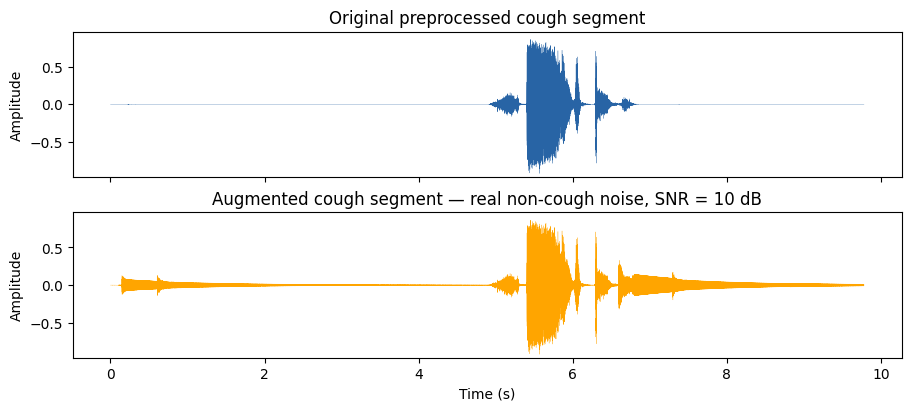

In [67]:
time = np.arange(len(y_original)) / SR

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

common_limit = 1.05 * max(
    np.max(np.abs(y_original)),
    np.max(np.abs(y_augmented)),
)

axes[0].plot(
    time,
    y_original,
    color="#2864A5",
    linewidth=0.2,
)
axes[0].set_title(
    "Original preprocessed cough segment",
    fontsize=12,
)
axes[0].set_ylabel("Amplitude")
axes[0].set_ylim(-common_limit, common_limit)

axes[1].plot(
    time,
    y_augmented,
    color="orange",
    linewidth=0.2,
)
axes[1].set_title(
    "Augmented cough segment — real non-cough noise, SNR = 10 dB",
    fontsize=12,
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_ylim(-common_limit, common_limit)

fig.savefig(
    FIGURE_DIR / "stage1_cough_noise_augmentation_10db.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "stage1_cough_noise_augmentation_10db.pdf",
    bbox_inches="tight",
)

plt.show()

GRAFICAS TOS/NO TOS ORIGINALES Y MFCCS + DELTAS

In [68]:
def extract_mfcc_sequences(signal):
    mfcc = librosa.feature.mfcc(
        y=np.asarray(signal, dtype=np.float32),
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window="hann",
        center=True,
        pad_mode="constant",
        power=2.0,
        n_mels=N_MELS,
        fmin=0.0,
        fmax=SR / 2,
        dct_type=2,
        norm="ortho",
        lifter=0,
    )

    mfcc_delta = librosa.feature.delta(
        mfcc,
        width=9,
        order=1,
        mode="interp",
    )

    mfcc_delta2 = librosa.feature.delta(
        mfcc,
        width=9,
        order=2,
        mode="interp",
    )

    return mfcc, mfcc_delta, mfcc_delta2


mfcc_no_cough, delta_no_cough, delta2_no_cough = (
    extract_mfcc_sequences(y_no_cough)
)

mfcc_cough, delta_cough, delta2_cough = (
    extract_mfcc_sequences(y_cough)
)

# Escalado común, únicamente para escuchar los audios en el notebook
playback_peak = max(
    float(np.max(np.abs(y_no_cough))),
    float(np.max(np.abs(y_cough))),
)

playback_scale = max(1.0, playback_peak / 0.999)

y_no_cough_play = y_no_cough / playback_scale
y_cough_play = y_cough / playback_scale

print("Peak no-cough original:", np.max(np.abs(y_no_cough)))
print("Peak cough original:", np.max(np.abs(y_cough)))
print("Factor común de reproducción:", playback_scale)

display(Markdown("### 1. Audio non-cough"))
display(
    Audio(
        y_no_cough_play,
        rate=SR,
        normalize=False,
    )
)

display(Markdown("### 2. Audio cough"))
display(
    Audio(
        y_cough_play,
        rate=SR,
        normalize=False,
    )
)


Peak no-cough original: 0.936232
Peak cough original: 0.9165203
Factor común de reproducción: 1.0


### 1. Audio non-cough

### 2. Audio cough

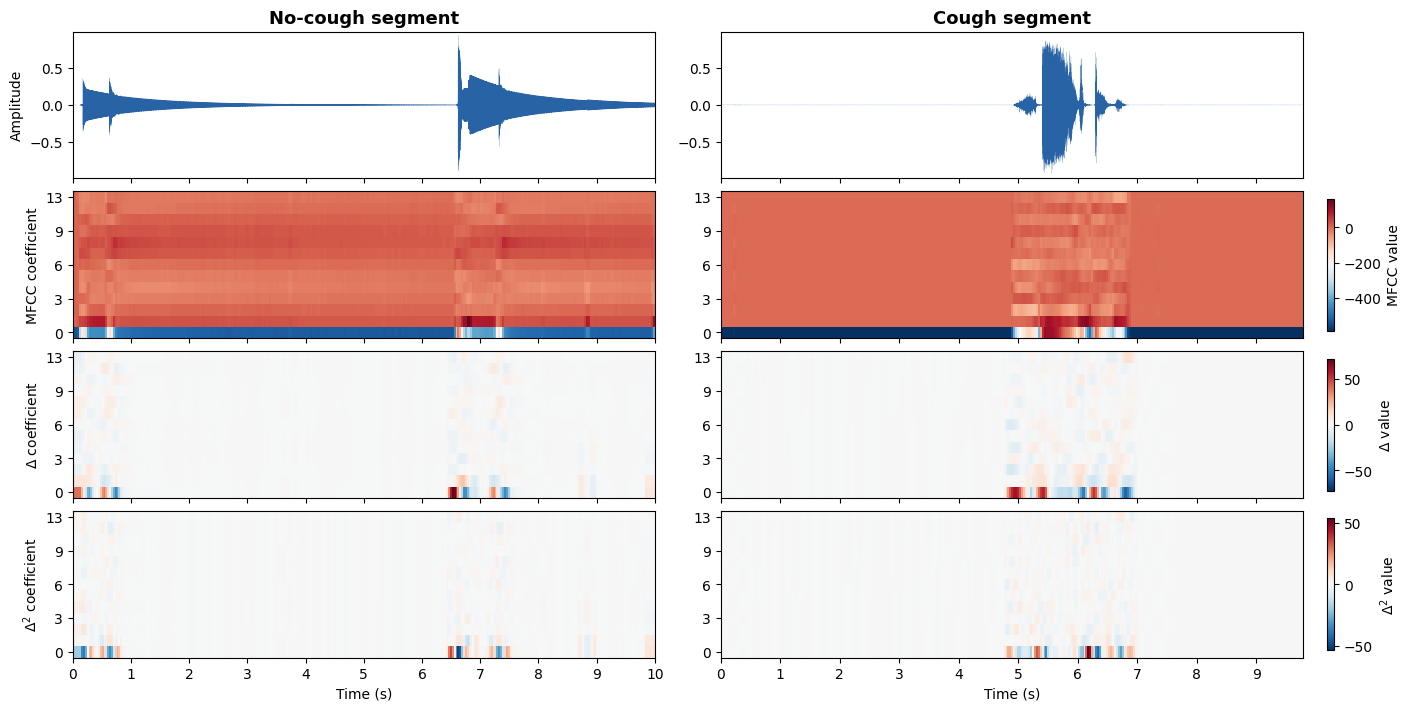

In [69]:
signals = [y_no_cough, y_cough]

representations = [
    (mfcc_no_cough, mfcc_cough),
    (delta_no_cough, delta_cough),
    (delta2_no_cough, delta2_cough),
]

column_titles = [
    "No-cough segment",
    "Cough segment",
]

row_labels = [
    "Amplitude",
    "MFCC coefficient",
    r"$\Delta$ coefficient",
    r"$\Delta^2$ coefficient",
]

mfcc_values = np.concatenate([
    mfcc_no_cough.ravel(),
    mfcc_cough.ravel(),
])

mfcc_limits = np.percentile(
    mfcc_values,
    [1, 99],
)

delta_values = np.concatenate([
    delta_no_cough.ravel(),
    delta_cough.ravel(),
])

delta_limit = np.percentile(
    np.abs(delta_values),
    99,
)

delta2_values = np.concatenate([
    delta2_no_cough.ravel(),
    delta2_cough.ravel(),
])

delta2_limit = np.percentile(
    np.abs(delta2_values),
    99,
)
# ---------------------------------------------------------------------
# Límites de color compartidos entre tos y no tos
# ---------------------------------------------------------------------
mfcc_values = np.concatenate(
    [mfcc_no_cough.ravel(), mfcc_cough.ravel()]
)
mfcc_limits = (
    float(np.min(mfcc_values)),
    float(np.max(mfcc_values)),
)

delta_limit = float(
    max(
        np.max(np.abs(delta_no_cough)),
        np.max(np.abs(delta_cough)),
    )
)

delta2_limit = float(
    max(
        np.max(np.abs(delta2_no_cough)),
        np.max(np.abs(delta2_cough)),
    )
)


fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 7),
    sharex="col",
    constrained_layout=True,
)

images = {}


# ---------------------------------------------------------------------
# Primera fila: formas de onda
# ---------------------------------------------------------------------
waveform_limit = 1.05 * max(
    np.max(np.abs(y_no_cough)),
    np.max(np.abs(y_cough)),
)

for column, signal in enumerate(signals):
    time = np.arange(len(signal)) / SR

    axes[0, column].plot(
        time,
        signal,
        color="#2864A5",
        linewidth=0.1,
    )

    axes[0, column].set_title(
        column_titles[column],
        fontsize=13,
        fontweight="bold",
    )

    axes[0, column].set_xlim(0, len(signal) / SR)
    axes[0, column].set_ylim(
        -waveform_limit,
        waveform_limit,
    )


# ---------------------------------------------------------------------
# Filas 2–4: MFCC, delta y delta cuadrado
# ---------------------------------------------------------------------
for column in range(2):
    mfcc_matrix = representations[0][column]
    delta_matrix = representations[1][column]
    delta2_matrix = representations[2][column]

    images[1] = librosa.display.specshow(
        mfcc_matrix,
        sr=SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis=None,
        cmap="RdBu_r",
        vmin=mfcc_limits[0],
        vmax=mfcc_limits[1],
        ax=axes[1, column],
    )

    images[2] = librosa.display.specshow(
        delta_matrix,
        sr=SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis=None,
        cmap="RdBu_r",
        vmin=-delta_limit,
        vmax=delta_limit,
        ax=axes[2, column],
    )

    images[3] = librosa.display.specshow(
        delta2_matrix,
        sr=SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis=None,
        cmap="RdBu_r",
        vmin=-delta2_limit,
        vmax=delta2_limit,
        ax=axes[3, column],
    )

    duration = len(signals[column]) / SR

    for row in range(1, 4):
        axes[row, column].set_xlim(0, duration)
        axes[row, column].set_yticks([0, 3, 6, 9, 12])
        axes[row, column].set_yticklabels([0, 3, 6, 9, 13])


# Etiquetas verticales
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label)

for row in range(4):
    axes[row, 1].set_ylabel("")

# Solo la última fila necesita el título del eje temporal
for column in range(2):
    axes[3, column].set_xlabel("Time (s)")

# Eliminar etiquetas temporales de las filas superiores
for row in range(3):
    for column in range(2):
        axes[row, column].tick_params(labelbottom=False)


# Una barra de color común para las dos columnas de cada representación
fig.colorbar(
    images[1],
    ax=axes[1, :].tolist(),
    label="MFCC value",
    shrink=0.90,
    pad=0.02,
)

fig.colorbar(
    images[2],
    ax=axes[2, :].tolist(),
    label=r"$\Delta$ value",
    shrink=0.90,
    pad=0.02,
)

fig.colorbar(
    images[3],
    ax=axes[3, :].tolist(),
    label=r"$\Delta^2$ value",
    shrink=0.90,
    pad=0.02,
)

fig.savefig(
    FIGURE_DIR / "stage1_waveform_mfcc_delta_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "stage1_waveform_mfcc_delta_comparison.pdf",
    bbox_inches="tight",
)
for row in range(3):
    for column in range(2):
        axes[row, column].set_xlabel("")

for column in range(2):
    axes[3, column].set_xlabel("Time (s)")
plt.show()

Clases: [0 1]
Intercept: -3.6124318435462106
Coeficientes diferentes de cero: 92 / 117


,feature,coefficient,absolute_coefficient
104,max_Delta2_c0,2.007384,2.007384
78,max_MFCC_c0,1.737792,1.737792
65,std_Delta2_c0,-1.118864,1.118864
91,max_Delta_c0,1.104633,1.104633
0,mean_MFCC_c0,-1.011249,1.011249
79,max_MFCC_c1,0.985035,0.985035
41,std_MFCC_c2,-0.769139,0.769139
42,std_MFCC_c3,-0.757808,0.757808
13,mean_Delta_c0,-0.714342,0.714342
10,mean_MFCC_c10,-0.564021,0.564021


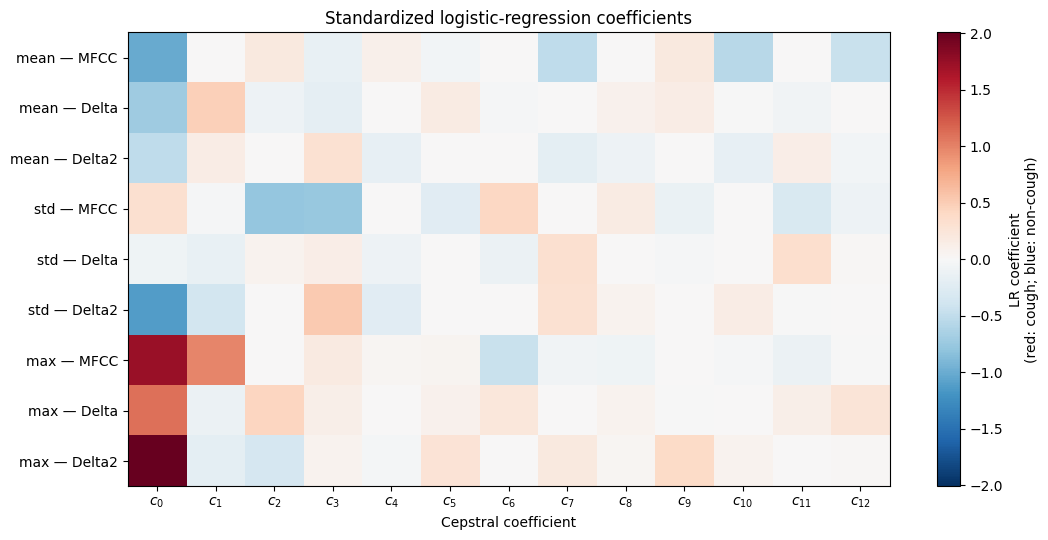

In [70]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


MODEL_PATH = (
    ROOT
    / "results_stage1_cough_no_cough"
    / "mfcc117_lr_fsd50k_cough_segments_random"
    / "full"
    / "stage1_lr_fsd50k_cough_segments.joblib"
)

model = joblib.load(MODEL_PATH)

scaler = model.named_steps["scaler"]
classifier = model.named_steps["classifier"]

print("Clases:", classifier.classes_)
print("Intercept:", classifier.intercept_[0])
print(
    "Coeficientes diferentes de cero:",
    np.count_nonzero(classifier.coef_),
    "/",
    classifier.coef_.size,
)

statistics = ["mean", "std", "max"]
families = ["MFCC", "Delta", "Delta2"]

feature_names = [
    f"{statistic}_{family}_c{coefficient}"
    for statistic in statistics
    for family in families
    for coefficient in range(13)
]

coefficients = classifier.coef_[0]

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})

coefficient_table["absolute_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

display(
    coefficient_table
    .sort_values("absolute_coefficient", ascending=False)
    .head(25)
)

coefficient_matrix = coefficients.reshape(9, 13)

row_names = [
    f"{statistic} — {family}"
    for statistic in statistics
    for family in families
]

limit = np.max(np.abs(coefficient_matrix))

fig, ax = plt.subplots(figsize=(11, 5.5))

image = ax.imshow(
    coefficient_matrix,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
)

ax.set_xticks(np.arange(13))
ax.set_xticklabels([f"$c_{{{i}}}$" for i in range(13)])

ax.set_yticks(np.arange(9))
ax.set_yticklabels(row_names)

ax.set_xlabel("Cepstral coefficient")
ax.set_title("Standardized logistic-regression coefficients")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label(
    "LR coefficient\n(red: cough; blue: non-cough)"
)

plt.tight_layout()
plt.show()

Logit: 6.202389533090639
Probabilidad de tos: 0.997979503636825
Predicción: cough


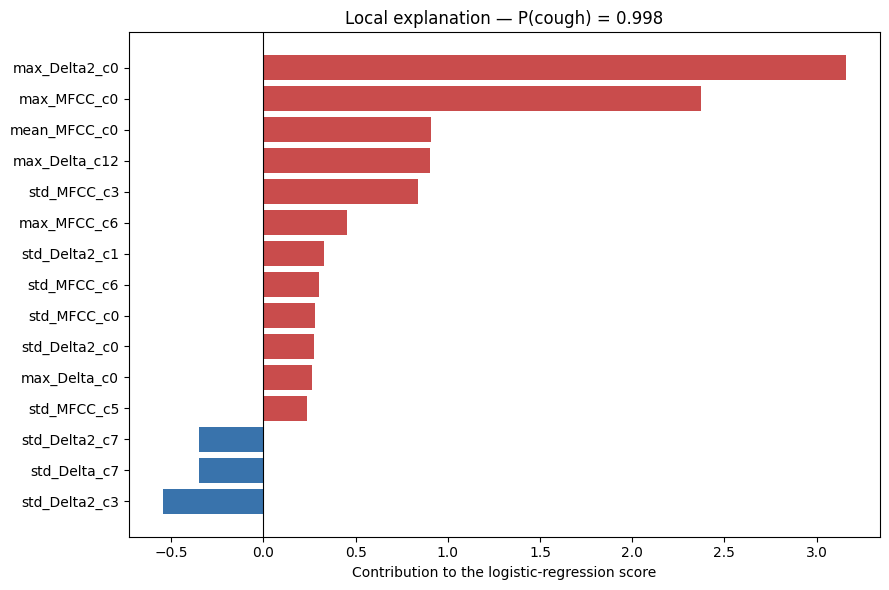

In [72]:
def extract_mfcc117_for_explanation(signal):
    mfcc, delta, delta2 = extract_mfcc_sequences(signal)

    temporal_coefficients = np.vstack([
        mfcc,
        delta,
        delta2,
    ])

    return np.concatenate([
        np.mean(temporal_coefficients, axis=1),
        np.std(temporal_coefficients, axis=1),
        np.max(temporal_coefficients, axis=1),
    ]).astype(np.float32)

x = extract_mfcc117_for_explanation(y_cough)

x_standardized = scaler.transform(x.reshape(1, -1))[0]

local_contributions = (
    classifier.coef_[0] * x_standardized
)

logit = (
    classifier.intercept_[0]
    + local_contributions.sum()
)

probability = model.predict_proba(
    x.reshape(1, -1)
)[0, 1]

prediction = int(probability >= 0.5)

print("Logit:", logit)
print("Probabilidad de tos:", probability)
print("Predicción:", "cough" if prediction == 1 else "no-cough")


local_table = pd.DataFrame({
    "feature": feature_names,
    "standardized_value": x_standardized,
    "model_coefficient": classifier.coef_[0],
    "contribution": local_contributions,
})

local_table["absolute_contribution"] = (
    local_table["contribution"].abs()
)

top_local = (
    local_table
    .sort_values("absolute_contribution", ascending=False)
    .head(15)
    .sort_values("contribution")
)

colors = np.where(
    top_local["contribution"] > 0,
    "#C94C4C",   # hacia tos
    "#3973AC",   # hacia no tos
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_local["feature"],
    top_local["contribution"],
    color=colors,
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Contribution to the logistic-regression score")
ax.set_title(
    f"Local explanation — P(cough) = {probability:.3f}"
)

plt.tight_layout()
plt.show()

grficas de lo que usa para clasificar de varios ejemplos

In [73]:
FEATURES_DIR = (
    ROOT
    / "features_extracted_stage1_fsd50k_cough_segments_random"
    / "mfcc117"
)

X_train = np.load(FEATURES_DIR / "X_train.npy")
y_train = np.load(FEATURES_DIR / "y_train.npy")

train_manifest = pd.read_csv(
    FEATURES_DIR / "metadata_features_train.csv",
    low_memory=False,
)

assert len(X_train) == len(y_train) == len(train_manifest)
assert np.array_equal(
    train_manifest["feature_row"].to_numpy(),
    np.arange(len(train_manifest)),
)


N_SAMPLES = 15

# None: muestras diferentes cada vez
# 42: selección reproducible
RANDOM_STATE = 42

cough_indices = np.flatnonzero(y_train == 1)

rng = np.random.default_rng(RANDOM_STATE)

selected_indices = rng.choice(
    cough_indices,
    size=min(N_SAMPLES, len(cough_indices)),
    replace=False,
)

X_selected = X_train[selected_indices]

selected_metadata = (
    train_manifest
    .iloc[selected_indices]
    .reset_index(drop=True)
    .copy()
)

selected_metadata.insert(
    0,
    "sample",
    [f"C{i + 1:02d}" for i in range(len(selected_metadata))]
)

display(
    selected_metadata[
        [
            "sample",
            "uuid_segmento",
            "dataset_origin",
            "quality",
            "segment_duration",
        ]
    ]
)

X_selected_standardized = scaler.transform(X_selected)

# Contribución de cada variable a cada muestra
contributions = (
    X_selected_standardized
    * classifier.coef_[0][None, :]
)

probabilities = model.predict_proba(X_selected)[:, 1]
predictions = (probabilities >= 0.5).astype(int)

selected_metadata["cough_probability"] = probabilities
selected_metadata["prediction"] = predictions
selected_metadata["correctly_detected"] = predictions == 1

display(
    selected_metadata[
        [
            "sample",
            "uuid_segmento",
            "dataset_origin",
            "cough_probability",
            "prediction",
            "correctly_detected",
        ]
    ]
)

print(
    "Toses detectadas:",
    f"{predictions.sum()}/{len(predictions)}"
)

,sample,uuid_segmento,dataset_origin,quality,segment_duration
0,C01,1af7b784-13d3-41b4-8f21-89c417b96256_seg_0,COUGHVID,good,9.720000
1,C02,1ca49e1b-7b7a-4442-8603-a41083fc49e3_seg_0,COUGHVID,good,9.960000
2,C03,ae9ae0a2-f646-4f2d-a8d2-050d71fc3a29_seg_0,COUGHVID,ok,9.540000
3,C04,ccdfd92d-e6f1-42ce-8781-ff6d04f7f628_seg_0,COUGHVID,ok,9.960000
4,C05,372846d2-d0b1-435b-bd1c-2580506dc502_seg_0,COUGHVID,good,7.380000
5,C06,c0687f80-4d3b-473e-9cd5-7ade1b43f528_seg_0,COUGHVID,good,9.900000
6,C07,1a0d7c38-e644-4c5d-9ba0-bf9bdc0bffd6_seg_0,COUGHVID,poor,7.920000
7,C08,c52cae2c-3250-45e4-9c3a-4cfb08ef9c98_seg_0,COUGHVID,good,9.900000
8,C09,756d7aa4-e12a-4eb3-b119-2b8a7db0abb6_seg_0,COUGHVID,good,5.520000
9,C10,e80023d9-392a-407a-9580-9c66eb45d7bd_seg_0,COUGHVID,good,9.420000


,sample,uuid_segmento,dataset_origin,cough_probability,prediction,correctly_detected
0,C01,1af7b784-13d3-41b4-8f21-89c417b96256_seg_0,COUGHVID,0.988882,1,True
1,C02,1ca49e1b-7b7a-4442-8603-a41083fc49e3_seg_0,COUGHVID,0.987880,1,True
2,C03,ae9ae0a2-f646-4f2d-a8d2-050d71fc3a29_seg_0,COUGHVID,0.941633,1,True
3,C04,ccdfd92d-e6f1-42ce-8781-ff6d04f7f628_seg_0,COUGHVID,0.940472,1,True
4,C05,372846d2-d0b1-435b-bd1c-2580506dc502_seg_0,COUGHVID,0.956574,1,True
5,C06,c0687f80-4d3b-473e-9cd5-7ade1b43f528_seg_0,COUGHVID,0.801169,1,True
6,C07,1a0d7c38-e644-4c5d-9ba0-bf9bdc0bffd6_seg_0,COUGHVID,0.997663,1,True
7,C08,c52cae2c-3250-45e4-9c3a-4cfb08ef9c98_seg_0,COUGHVID,0.999254,1,True
8,C09,756d7aa4-e12a-4eb3-b119-2b8a7db0abb6_seg_0,COUGHVID,0.959408,1,True
9,C10,e80023d9-392a-407a-9580-9c66eb45d7bd_seg_0,COUGHVID,0.980501,1,True


Toses detectadas: 15/15


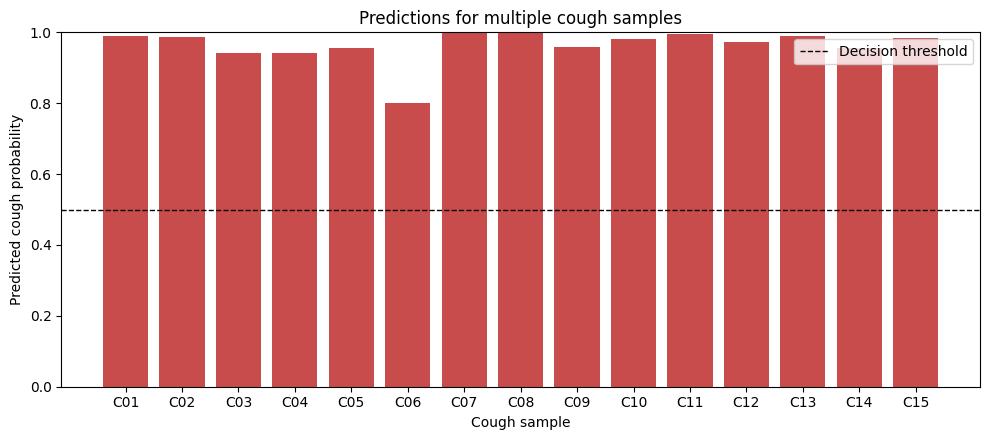

In [74]:
fig, ax = plt.subplots(figsize=(10, 4.5))

colors = np.where(
    probabilities >= 0.5,
    "#C94C4C",  # correctamente detectada como tos
    "#3973AC",  # falso negativo
)

ax.bar(
    selected_metadata["sample"],
    probabilities,
    color=colors,
)

ax.axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Decision threshold",
)

ax.set_ylim(0, 1)
ax.set_xlabel("Cough sample")
ax.set_ylabel("Predicted cough probability")
ax.set_title("Predictions for multiple cough samples")
ax.legend()

plt.tight_layout()
plt.show()

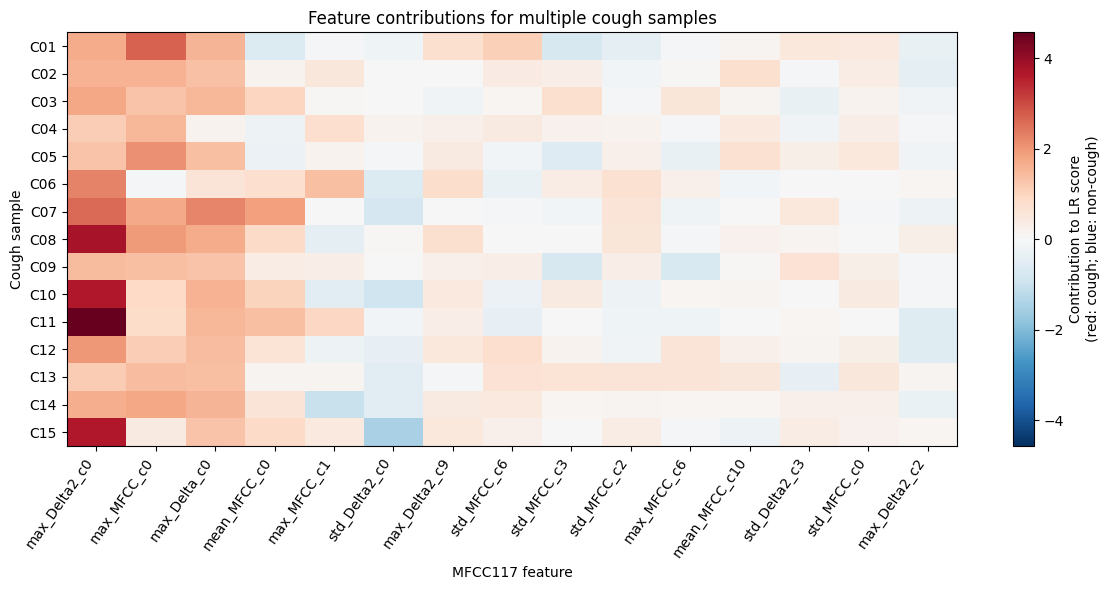

In [75]:
mean_absolute_contribution = np.mean(
    np.abs(contributions),
    axis=0,
)

top_feature_indices = np.argsort(
    mean_absolute_contribution
)[-15:]

top_feature_indices = top_feature_indices[::-1]

top_feature_names = [
    feature_names[index]
    for index in top_feature_indices
]

contribution_heatmap = contributions[
    :,
    top_feature_indices,
]

limit = np.max(np.abs(contribution_heatmap))

fig, ax = plt.subplots(figsize=(12, 6))

image = ax.imshow(
    contribution_heatmap,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
)

ax.set_xticks(np.arange(len(top_feature_names)))
ax.set_xticklabels(
    top_feature_names,
    rotation=55,
    ha="right",
)

ax.set_yticks(np.arange(len(selected_metadata)))
ax.set_yticklabels(selected_metadata["sample"])

ax.set_xlabel("MFCC117 feature")
ax.set_ylabel("Cough sample")
ax.set_title("Feature contributions for multiple cough samples")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label(
    "Contribution to LR score\n"
    "(red: cough; blue: non-cough)"
)

plt.tight_layout()
plt.show()

In [76]:
contribution_summary = pd.DataFrame({
    "feature": feature_names,
    "lr_coefficient": classifier.coef_[0],
    "mean_contribution": contributions.mean(axis=0),
    "mean_absolute_contribution": np.abs(contributions).mean(axis=0),
    "fraction_pushing_towards_cough": (
        contributions > 0
    ).mean(axis=0),
})

display(
    contribution_summary
    .sort_values(
        "mean_absolute_contribution",
        ascending=False,
    )
    .head(20)
)

,feature,lr_coefficient,mean_contribution,mean_absolute_contribution,fraction_pushing_towards_cough
104,max_Delta2_c0,2.007384,2.281893,2.281893,1.000000
78,max_MFCC_c0,1.737792,1.374847,1.384548,0.933333
91,max_Delta_c0,1.104633,1.368800,1.368800,1.000000
0,mean_MFCC_c0,-1.011249,0.568440,0.715348,0.800000
79,max_MFCC_c1,0.985035,0.163802,0.462940,0.666667
65,std_Delta2_c0,-1.118864,-0.356030,0.388192,0.200000
113,max_Delta2_c9,0.384565,0.342685,0.371134,0.866667
45,std_MFCC_c6,0.420384,0.222561,0.370986,0.666667
42,std_MFCC_c3,-0.757808,0.049431,0.337966,0.666667
41,std_MFCC_c2,-0.769139,0.162468,0.327527,0.600000
